The study presents a model of guard cells and their interactions that influence stomatal aperture width. Below is a detailed summary along with the key equations and concepts you would need to reimplement the model.

Overview of the Model

1. Principle Function: The stomatal aperture width W is a function of the turgor pressures in the guard cells (Pg​) and the adjacent epidermal cells (Ps​). The model focuses on how these pressures interact and how the deformation of guard cells can affect stomatal opening.

2. Geometry: The guard cells can be modeled as elliptical or toroidal shapes. The assumption is that they behave like orthotropic shells instead of simple beams due to their geometry and material properties.

3. Multilinear Relationship: The aperture width W is described by a multilinear relationship with pressures Pg​ and Ps​ rather than just the difference (Pg​−Ps​). This relationship can be expressed as:

W=f(Pg​,Ps​)=a1​Pg​+a2​Ps​+a3​Pg​Ps​+…

where a1​,a2​, and a3​ are constants determined by experimental data.

Key Components of the Model

1. Pressure Influence Coefficients: The model defines coefficients that relate the changes in guard cell pressure to deformation:

ddPg​​=[(−6)−(0)][6.0−12.0]​=1.00
ddPs​​=[(−6)−(0)][0.9−6.5]​=0.93

These coefficients measure how sensitive the aperture width is to changes in guard and epidermal cell pressures.

1. Finite Element Analysis: The deformation of the guard cells is analyzed using finite element methods. The model employs an assemblage of doubly-curved triangular finite elements, which account for the complexities when the guard cells deform.

- You would need to create a global stiffness matrix from individual matrices of each finite element and then solve the system of equations representing the equilibrium states of the guard cells.

Analytical Steps

1. Define Geometry and Parameters: Set up the geometric parameters of the guard cells based on experimental values (like pore length and width).

2. Solve for Deformation: Using the finite element method, you assemble the element matrices based on the defined boundary conditions and continuity requirements.

3. Calculate Stomatal Aperture: Once the deformation due to pressures is determined, calculate the stomatal aperture width using the established multilinear relationships.

4. Parameter Adjustment: Using empirical data, adjust the coefficients to better fit observed stomatal behaviors across different plant species.

Equations

1. Aperture Width Equation:
W=a1​Pg​+a2​Ps​+a3​Pg​Ps​

2. Finite Element Method Setup:

- Formulate the stiffness matrices for individual elements.

- Define boundary conditions, and assemble them into a global stiffness matrix.

1. Deformation Relationship:

- The relationship can be derived from:
W=Function of elastic properties and pressures

Conclusion

This model offers a comprehensive approach to understanding how guard cell pressure, geometry, and material properties influence stomatal function. By implementing this mathematically with finite element analysis, one can simulate how changes in environmental conditions may affect stomatal dynamics in plants.

In [5]:
import numpy as np
from sfepy.discrete import FieldVariable, Integral, Equation, Equations, Problem
from sfepy.discrete import Domain
from sfepy.discrete.fem import Field
from sfepy.terms import Term
from sfepy.solvers.ls import ScipyDirect
from sfepy.solvers.nls import Newton
from sfepy.discrete.conditions import EssentialBC
from sfepy.mesh.generators import gen_block_mesh
from sfepy.postprocess.viewer import Viewer

# Step 1: Generate a simple rectangular mesh (length=1.0, height=0.5)
dims = [1.0, 0.5]  # [width, height]
shape = [10, 5]    # Number of elements in x and y direction
mesh = gen_block_mesh(dims, shape, [0, 0], name='generated_mesh')

# Step 2: Define the computational domain
domain = Domain('domain', mesh)
omega = domain.create_region('Omega', 'all')

# Step 3: Define the displacement field (vector field for 2D elasticity)
field = Field.from_args('displacement', np.float64, 'vector', omega, approx_order=1)

# Step 4: Define unknown (u) and test (v) variables
u = FieldVariable('u', 'unknown', field)
v = FieldVariable('v', 'test', field, primary_var_name='u')

# Step 5: Define material properties (Elasticity)
youngs_modulus = 200e3  # Pascals
poisson_ratio = 0.3

# Define the elasticity term
integral = Integral('i', order=2)
term = Term.new('dw_lin_elastic.2.Omega( solid.lame, u, v )',
                integral, omega, solid={'lame': [youngs_modulus, poisson_ratio]}, u=u, v=v)

# Step 6: Apply boundary conditions
fixed = EssentialBC('fixed', domain.create_region('LeftEdge', 'vertices in x < 1e-6'), {'u.all': 0.0})  # Fix left edge

# Step 7: Define and solve equations
equations = Equations([Equation('elasticity', term)])
ls = ScipyDirect({})
nls = Newton({'i_max': 10, 'eps_a': 1e-10})

problem = Problem('elasticity', equations=equations)
problem.set_bcs(ebcs=[fixed])
problem.set_solver(nls)
problem.solve()

# Step 8: Save and visualize results
problem.save_state('output.vtk')
viewer = Viewer('output.vtk')
viewer()




ModuleNotFoundError: No module named 'sfepy.mesh.generators'

In [6]:
import sfepy
import sfepy.mesh
print(dir(sfepy.mesh))




['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [ ]:
import numpy as np
import trimesh
from shapely.geometry import Polygon

def extract_polygons_manual(path2d):
    """
    Manually extract closed polygons from a trimesh Path2D object.
    This avoids using methods (like polygons_full) that depend on rtree.
    
    Parameters:
      path2d (trimesh.path.Path2D): The 2D path from a mesh section.
      
    Returns:
      list: A list of shapely Polygon objects.
    """
    polygons = []
    # Each entity represents a connected set of vertices.
    for entity in path2d.entities:
        # Get the indices of the vertices in this entity.
        pts_idx = entity.points
        # Retrieve the coordinates from the vertices array.
        pts = path2d.vertices[pts_idx]
        # Check if the entity forms a closed loop:
        if np.allclose(pts[0], pts[-1]):
            poly = Polygon(pts)
            if poly.is_valid:
                polygons.append(poly)
    return polygons

def slice_torus(mesh, torus_center, major_radius, num_slices):
    slices = []
    torus_center = np.array(torus_center)
    
    for i in range(num_slices):
        angle = 2 * np.pi * i / num_slices  # Evenly distribute slices along the torus' central axis
        
        # Compute a point on the torus' central axis (spine of the torus)
        spine_point = torus_center + np.array([
            np.cos(angle) * major_radius,  
            np.sin(angle) * major_radius,
            0  # Assuming torus is in the XY plane
        ])
        
        # Tangent to the torus' central axis at this point (direction of movement)
        tangent = np.array([-np.sin(angle), np.cos(angle), 0])  # Derivative of the spine curve
        
        # The correct slicing normal should be perpendicular to this tangent and in the Z-direction
        normal = np.cross(tangent, [0, 0, 1])  # Perpendicular to both tangent and Z
        
        # Slice the torus
        slice_path = mesh.section(plane_origin=spine_point, plane_normal=normal)
        
        if slice_path is not None:
            slice_2D, to_3D = slice_path.to_planar()
            slices.append({
                'slice_3D': slice_path,
                'slice_2D': slice_2D,
                'transform': to_3D,
                'angle': angle
            })
        else:
            slices.append(None)
            
    return slices

if __name__ == '__main__':
    # Create the torus mesh
    torus_mesh = trimesh.creation.torus(major_radius=2.0, minor_radius=0.5)
    
    center = [0, 0, 0]
    major_radius = 2.0  
    num_slices = 12
    
    slices = slice_torus(torus_mesh, center, major_radius, num_slices)
    
    if slices[0] is not None:
        slice_2D = slices[0]['slice_2D']
        # Manually extract closed polygons
        polygons = extract_polygons_manual(slice_2D)
        
        if polygons:
            # Extrude the first polygon to create a thin 3D mesh for visualization.
            slice_mesh = trimesh.creation.extrude_polygon(polygons[0], height=0.01, engine='triangle')
            scene = trimesh.Scene([torus_mesh, slice_mesh])
            scene.show()
        else:
            print("No closed polygon found in the 2D slice.")
    else:
        print("No slice found at the first interval.")


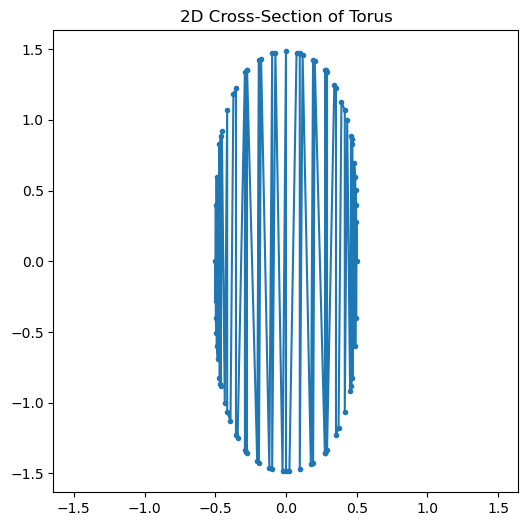

In [42]:
import matplotlib.pyplot as plt

# Extract the 2D cross-section
slice_2D = slices[0]['slice_2D']

# Get the vertices
vertices = slice_2D.vertices

# Plot the cross-section
plt.figure(figsize=(6,6))
plt.plot(vertices[:, 0], vertices[:, 1], 'o-', markersize=3)  # 'o-' plots points and connects them
plt.axis('equal')  # Ensure aspect ratio is preserved
plt.title("2D Cross-Section of Torus")
plt.show()


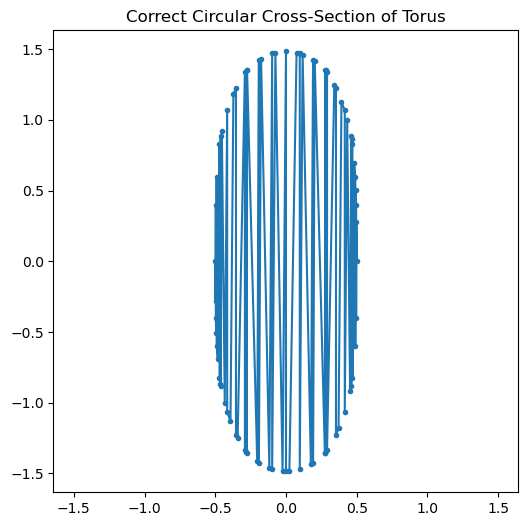

In [ ]:
import trimesh

# Extract the 3D cross-section
slice_3D = slices[0]['slice_3D']

# Create a scene with both the torus and the slice
scene = trimesh.Scene([torus_mesh, slice_3D])

# Display in an interactive viewer
scene.show()


In [76]:
import trimesh
import numpy as np

# Define the major radius and center of the torus
major_radius = 2.0  # Example value for major radius of the torus
minor_radius = 0.5  # Minor radius of the torus
center = [0, 0, 0]  # Center of the torus

# Create the torus mesh using trimesh
torus_mesh = trimesh.creation.torus(major_radius=major_radius, minor_radius=minor_radius)

# Extract the edges of the torus mesh to create a wireframe
torus_edges = torus_mesh.edges
torus_wireframe_points = torus_mesh.vertices[torus_edges]

# Create a new mesh using the extracted edges
torus_wireframe.visual.vertex_colors = np.array([[128, 128, 128, 255]] * torus_wireframe_points.shape[0])


# Convert spine points into a point cloud
num_spine_points = 100  # Number of points for visualization
angles = np.linspace(0, 2 * np.pi, num_spine_points)

spine_points = np.array([
    [
        np.cos(angle) * major_radius + center[0],  # X coordinate
        np.sin(angle) * major_radius + center[1],  # Y coordinate
        center[2]  # Z coordinate (constant)
    ] for angle in angles
])

# Convert spine points into a point cloud
spine_cloud = trimesh.points.PointCloud(spine_points)

# Set the color of the spine points to red
spine_cloud.visual.vertex_colors = np.array([[255, 0, 0, 255]] * len(spine_points))  # Red color

# Slice the torus to get 3D cross-section(s)
def slice_torus(mesh, torus_center, major_radius, num_slices):
    slices = []
    torus_center = np.array(torus_center)
    
    # Choose a normal that is constant (aligned with the symmetry axis)
    normal = np.array([0, 0, 1])  # Assuming the torus lies in the XY plane
    
    # Define evenly spaced slice heights along the Z-axis
    z_min, z_max = mesh.bounds[0, 2], mesh.bounds[1, 2]
    z_values = np.linspace(z_min, z_max, num_slices)

    for z in z_values:
        point = np.array([torus_center[0], torus_center[1], z])
        slice_path = mesh.section(plane_origin=point, plane_normal=normal)
        
        if slice_path is not None:
            slice_2D, to_3D = slice_path.to_planar()
            slices.append({
                'slice_3D': slice_path,
                'slice_2D': slice_2D,
                'transform': to_3D,
                'z': z
            })
        else:
            slices.append(None)
            
    return slices

# Call the slice_torus function and pass major_radius
slices = slice_torus(torus_mesh, center, major_radius, num_slices=10)

# Extract the first 3D slice
slice_3D = slices[0]['slice_3D'] if slices[0] is not None else None

# Create a scene with the wireframe, the slice, and the red spine
scene = trimesh.Scene([torus_wireframe, slice_3D, spine_cloud])

# Display in an interactive viewer
scene.show()


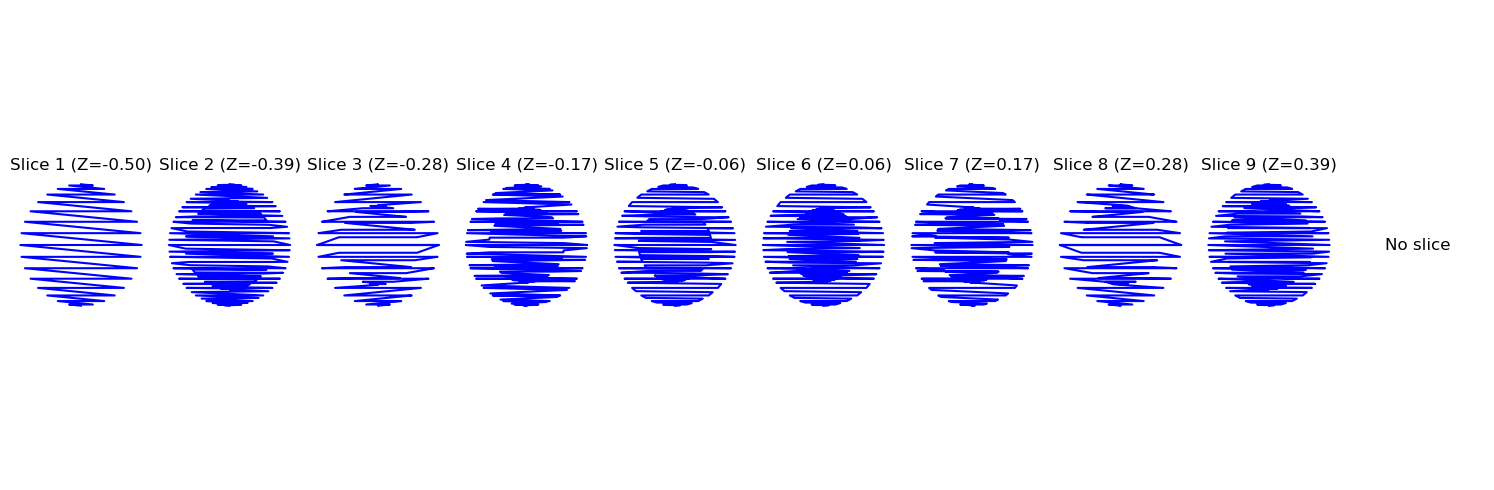

In [82]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

# Define the major radius and center of the torus
major_radius = 2.0  # Example value for major radius of the torus
minor_radius = 0.5  # Minor radius of the torus
center = [0, 0, 0]  # Center of the torus

# Create the torus mesh using trimesh
torus_mesh = trimesh.creation.torus(major_radius=major_radius, minor_radius=minor_radius)

# Slice the torus to get 2D cross-sections
def slice_torus(mesh, torus_center, major_radius, num_slices):
    slices = []
    torus_center = np.array(torus_center)
    
    # Choose a normal that is constant (aligned with the symmetry axis)
    normal = np.array([0, 0, 1])  # Assuming the torus lies in the XY plane
    
    # Define evenly spaced slice heights along the Z-axis
    z_min, z_max = mesh.bounds[0, 2], mesh.bounds[1, 2]
    z_values = np.linspace(z_min, z_max, num_slices)

    for z in z_values:
        point = np.array([torus_center[0], torus_center[1], z])
        slice_path = mesh.section(plane_origin=point, plane_normal=normal)
        
        if slice_path is not None:
            slice_2D, to_3D = slice_path.to_planar()
            slices.append({
                'slice_3D': slice_path,
                'slice_2D': slice_2D,
                'transform': to_3D,
                'z': z
            })
        else:
            slices.append(None)
            
    return slices

# Call the slice_torus function and pass major_radius
slices = slice_torus(torus_mesh, center, major_radius, num_slices=10)

# Prepare the plot
fig, axes = plt.subplots(1, len(slices), figsize=(15, 5))

# Plot each slice on the axes
for i, slice_data in enumerate(slices):
    if slice_data is not None:
        # Get the 2D slice and plot it
        slice_2D = slice_data['slice_2D']
        
        # Plot the 2D slice
        axes[i].plot(*slice_2D.vertices[:, :2].T, color='blue')  # Assuming the slice is in 2D XY plane
        axes[i].set_title(f"Slice {i+1} (Z={slice_data['z']:.2f})")
        axes[i].set_aspect('equal')
        axes[i].axis('off')  # Hide axes for a cleaner visualization
    else:
        axes[i].text(0.5, 0.5, 'No slice', ha='center', va='center', fontsize=12)
        axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


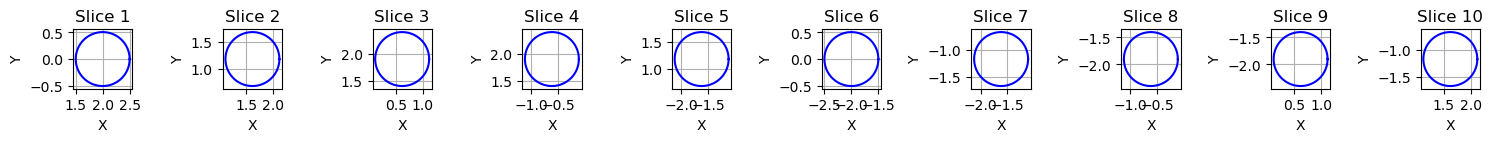

In [89]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

# Define the major radius and minor radius of the torus
major_radius = 2.0  # Major radius (distance from the center of the tube to the center of the torus)
minor_radius = 0.5  # Minor radius (radius of the tube)
center = [0, 0, 0]  # Center of the torus

# Create the torus mesh using trimesh
torus_mesh = trimesh.creation.torus(major_radius=major_radius, minor_radius=minor_radius)

# Function to generate slices perpendicular to the torus axis (perpendicular to the major radius circle)
def slice_torus(mesh, torus_center, major_radius, minor_radius, num_slices):
    slices = []
    torus_center = np.array(torus_center)
    
    # Define angles along the major circle of the torus (around the central axis)
    angles = np.linspace(0, 2 * np.pi, num_slices, endpoint=False)  # Angle along the torus circumference
    
    for angle in angles:
        # Parametrize the circle for each slice (perpendicular to the torus central axis)
        x_center = torus_center[0] + major_radius * np.cos(angle)
        y_center = torus_center[1] + major_radius * np.sin(angle)
        
        # Parametrize the circle that defines the cross-section (tube's minor radius)
        circle_angles = np.linspace(0, 2 * np.pi, 100)  # 100 points for smoothness
        x = x_center + minor_radius * np.cos(circle_angles)
        y = y_center + minor_radius * np.sin(circle_angles)
        z = np.zeros_like(x)  # All points are in the XY plane (no Z variation for each slice)
        
        # Stack X, Y, Z coordinates for the slice
        slice_points = np.vstack([x, y, z]).T
        slices.append(slice_points)
    
    return slices

# Call the slice_torus function and get the slice points
num_slices = 10  # Number of slices around the central axis (not vertical height)
slices = slice_torus(torus_mesh, center, major_radius, minor_radius, num_slices)

# Plot each cross-section side by side
fig, axes = plt.subplots(1, num_slices, figsize=(15, 5))

for i, slice_points in enumerate(slices):
    ax = axes[i]
    ax.plot(slice_points[:, 0], slice_points[:, 1], color='blue')
    ax.set_aspect('equal', 'box')  # This ensures the aspect ratio is equal
    ax.set_title(f'Slice {i+1}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.grid(True)

plt.tight_layout()
plt.show()


In [90]:
import trimesh
import numpy as np
from skimage import measure, morphology
from scipy.spatial.distance import cdist

# Load mesh

path_to_mesh ="/Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/mesh_1_2.obj"
mesh = trimesh.load_mesh(path_to_mesh)

# Convert to voxel grid
voxel_grid = mesh.voxelized(pitch=0.1)
voxels = voxel_grid.matrix

# Skeletonize the voxel grid
skeleton = morphology.skeletonize(voxels)

# Get coordinates of skeleton
skeleton_coords = np.argwhere(skeleton == 1)

# Get surface points from mesh
surface_points = mesh.vertices

# Calculate distances from surface points to skeleton
distances = cdist(surface_points, skeleton_coords)
min_distances = np.min(distances, axis=1)

# Find the major radius (average distance from skeleton)
major_radius = np.mean(min_distances)
print(f"Major radius: {major_radius}")

# Slice the mesh along Z-axis
def slice_mesh(mesh, num_slices, major_radius):
    slices = []
    torus_center = mesh.centroid
    normal = np.array([0, 0, 1])
    z_min, z_max = mesh.bounds[0, 2], mesh.bounds[1, 2]
    z_values = np.linspace(z_min, z_max, num_slices)

    for z in z_values:
        point = np.array([torus_center[0], torus_center[1], z])
        slice_path = mesh.section(plane_origin=point, plane_normal=normal)
        
        if slice_path is not None:
            slice_2D, to_3D = slice_path.to_planar()
            slices.append({
                'slice_3D': slice_path,
                'slice_2D': slice_2D,
                'transform': to_3D,
                'z': z
            })
        else:
            slices.append(None)

    return slices

# Apply the slice function
num_slices = 10
slices = slice_mesh(mesh, num_slices, major_radius)

# Create a scene to visualize the mesh and slices
scene = trimesh.Scene([mesh])

# Add slices to the scene
for slice_data in slices:
    if slice_data is not None:
        scene.add_geometry(slice_data['slice_3D'])

# Display the scene
scene.show()


Major radius: 99.6881057850247


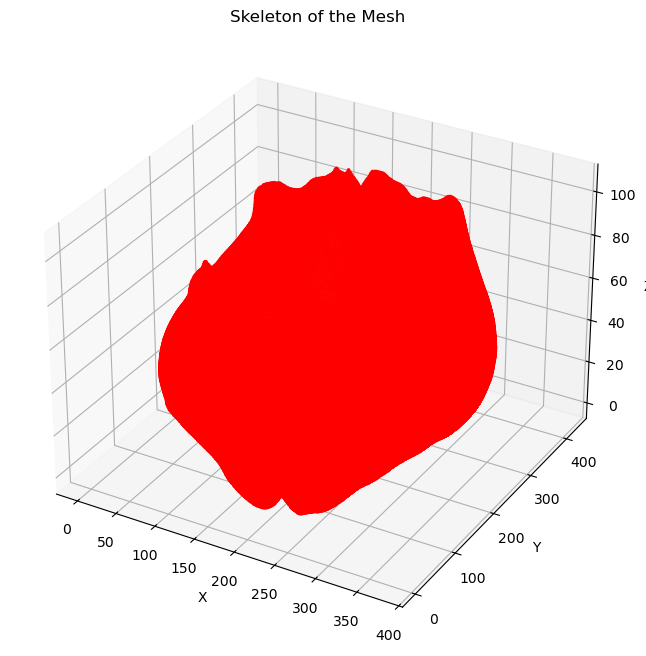

In [91]:
import trimesh
import numpy as np
from skimage import morphology
import matplotlib.pyplot as plt

# Load your mesh (adjust the path)
mesh = trimesh.load_mesh(path_to_mesh)

# Convert the mesh to a voxel grid (binary 3D grid)
voxel_grid = mesh.voxelized(pitch=0.1)  # Adjust pitch for resolution

# Get the 3D numpy array of the voxel grid
voxels = voxel_grid.matrix

# Skeletonize the 3D voxel grid
skeleton = morphology.skeletonize(voxels)

# Get coordinates of the skeleton
skeleton_coords = np.argwhere(skeleton == 1)

# Visualize the skeleton by plotting the coordinates
# Note: For large meshes, this might not be very clear, but it's useful for debugging

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the skeleton coordinates as points
ax.scatter(skeleton_coords[:, 0], skeleton_coords[:, 1], skeleton_coords[:, 2], s=1, c='r', label='Skeleton')

# Add labels and title
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Skeleton of the Mesh')

plt.show()


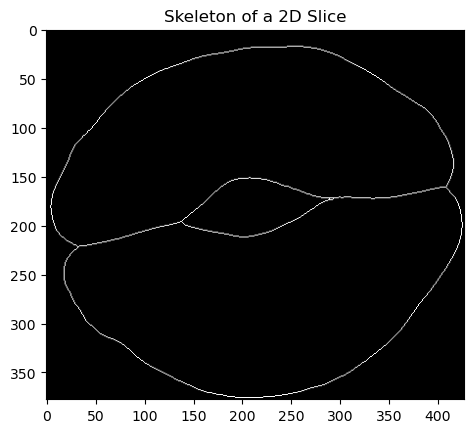

In [97]:
import trimesh
import numpy as np
import skimage
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

# Load the mesh (replace with your mesh path)
mesh = trimesh.load_mesh(path_to_mesh)

# Voxelize the mesh to convert it to a binary volume (use a suitable voxel size)
voxel_size = 0.1  # Adjust this to a reasonable value for your mesh
voxels = mesh.voxelized(pitch=voxel_size)

# Convert the binary voxel grid to a 2D slice for easier visualization
voxel_array = voxels.matrix  # A 3D binary numpy array

# Now, we need to skeletonize the voxel grid
# Skeletonize only one 2D slice as an example, let's take the middle slice
slice_index = voxel_array.shape[2] // 2
slice_voxel = voxel_array[:, :, slice_index]

# Perform skeletonization on this slice
skeleton = skeletonize(slice_voxel)

# Visualize the skeleton
plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton of a 2D Slice")
plt.show()


In [103]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt

# Load the mesh
mesh = trimesh.load_mesh(path_to_mesh)

# Find the boundary edges of the mesh
boundary_edges = mesh.edges_boundary

# Get the boundary vertices corresponding to the edges
boundary_vertices = mesh.vertices[boundary_edges]

# Compute the center of the mesh (we'll assume it as the centroid for simplicity)
center = mesh.centroid

# Calculate the distance of each boundary vertex from the center
distances = np.linalg.norm(boundary_vertices - center, axis=1)

# Classify points based on their distance from the center
inner_threshold = np.median(distances) - 0.1  # A small threshold to distinguish inner and outer boundary
outer_threshold = np.median(distances) + 0.1

# Classify the boundary vertices into inner and outer points
inner_points = boundary_vertices[distances < inner_threshold]
outer_points = boundary_vertices[distances > outer_threshold]

# Calculate the midpoints between corresponding inner and outer points
# For simplicity, let's assume the points are ordered and match by index
# (this will require tweaking for non-regular shapes)
midpoints = []

for outer_point in outer_points:
    # Find the closest point on the inner boundary to the outer point
    distances_to_inner = np.linalg.norm(inner_points - outer_point, axis=1)
    closest_inner_point = inner_points[np.argmin(distances_to_inner)]
    
    # Compute the midpoint
    midpoint = (outer_point + closest_inner_point) / 2
    midpoints.append(midpoint)

# Convert midpoints to a numpy array for easier manipulation
midpoints = np.array(midpoints)

# Plot the results
plt.figure(figsize=(6,6))
plt.scatter(midpoints[:, 0], midpoints[:, 1], c='r', label='Midpoints')
plt.title("Midpoints between Inner and Outer Walls")
plt.legend()
plt.show()


AttributeError: 'Trimesh' object has no attribute 'edges_boundary'

In [104]:
!conda install romicgal -c romi-eu

Retrieving notices: ...working... done
Solving environment: unsuccessful initial attempt using frozen solve. Retrying with flexible solve.
Solving environment: unsuccessful initial attempt using frozen solve. Retrying with flexible solve.

PackagesNotFoundError: The following packages are not available from current channels:

  - romicgal

Current channels:

  - https://conda.anaconda.org/romi-eu/osx-arm64
  - https://conda.anaconda.org/romi-eu/noarch
  - https://repo.anaconda.com/pkgs/main/osx-arm64
  - https://repo.anaconda.com/pkgs/main/noarch
  - https://repo.anaconda.com/pkgs/r/osx-arm64
  - https://repo.anaconda.com/pkgs/r/noarch
  - https://conda.anaconda.org/conda-forge/osx-arm64
  - https://conda.anaconda.org/conda-forge/noarch
  - https://conda.anaconda.org/bioconda/osx-arm64
  - https://conda.anaconda.org/bioconda/noarch

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at th

In [106]:
import sys

def clean_obj(input_file, output_file):
    """
    Cleans up an OBJ file by removing unnecessary entries (e.g., vn, vt, mtllib, usemtl).
    Retains only vertices (v) and faces (f).
    """
    try:
        with open(input_file, 'r') as infile, open(output_file, 'w') as outfile:
            for line in infile:
                # Keep only vertex (v) and face (f) lines
                if line.startswith('v ') or line.startswith('f '):
                    outfile.write(line)
                # Ignore other lines (vn, vt, mtllib, usemtl, etc.)
        print(f"Cleaned OBJ file saved to: {output_file}")
    except FileNotFoundError:
        print(f"Error: File not found: {input_file}")
    except Exception as e:
        print(f"An error occurred: {e}")

clean_obj("/Users/tomkinsm/stomata-air-mattress/Meshes/OBJ/mesh_1_2.obj", "mesh.obj")

Cleaned OBJ file saved to: mesh.obj


In [107]:
import open3d as o3d

mesh = o3d.io.read_triangle_mesh("build/mesh.obj")
o3d.io.write_triangle_mesh("build/mesh.ply", mesh)


True

In [108]:
import open3d as o3d

# Load the binary PLY
mesh = o3d.io.read_triangle_mesh("build/mesh.ply")

# Save as ASCII PLY
o3d.io.write_triangle_mesh("build/mesh_ascii.ply", mesh, write_ascii=True)


True

In [109]:
import open3d as o3d

# Load the PLY file
mesh = o3d.io.read_triangle_mesh("build/mesh_ascii.ply")

# Convert double to float (Open3D defaults to float)
o3d.io.write_triangle_mesh("build/mesh_fixed.ply", mesh, write_ascii=True)


True

In [112]:
## open and display skeleton.ply

import open3d as o3d

file_path = "build/skeleton.ply"
mesh = o3d.io.read_triangle_mesh(file_path)
if not mesh.has_vertices():
    print(f"Error: The PLY file '{file_path}' does not contain valid vertices.")

# Display the mesh
print(f"Loaded PLY file: {file_path}")
print(f"Number of vertices: {len(mesh.vertices)}")
print(f"Number of triangles: {len(mesh.triangles)}")
o3d.visualization.draw_geometries([mesh], window_name="PLY Viewer")


[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
Loaded PLY file: build/skeleton.ply
Number of vertices: 292
Number of triangles: 0
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed with empty triangle mesh.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Binding failed when preparing data.
[Open3D WARNING] [SimpleShaderForTriangleMesh] Something is wrong in compiling or binding.
[Open3D WA

In [3]:
import numpy as np
import trimesh
import math

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    """
    Returns the deformation offset for a given theta using a Gaussian function.
    This version accounts for the periodic nature of the angle.
    
    Parameters:
    - theta: The angular position(s) (in radians).
    - theta_center: The center of the Gaussian peak (in radians).
    - amplitude: The maximum additional radius at the peak.
    - sigma: The standard deviation of the Gaussian (controls the width).
    
    Returns:
    - Deformation value(s) to be added to the minor radius.
    """
    # Compute the minimal angular difference (accounting for periodicity)
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    """
    Generates a torus mesh with deformations in the minor radius at specified theta positions.
    
    Parameters:
    - R: Major radius (distance from the torus center to the center of the tube)
    - r: Base minor radius (radius of the tube)
    - num_theta: Number of divisions in the torus major angle (θ)
    - num_phi: Number of divisions in the tube angle (φ)
    - bulge_params: A list of dictionaries with keys:
          'theta_center': center position for the bulge,
          'amplitude': amplitude of the Gaussian deformation,
          'sigma': width of the bulge.
    
    Returns:
    - vertices: (N, 3) array of vertex positions.
    - faces: (M, 3) array of triangle face indices.
    """
    # Create angular grids.
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)  # major angle
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)        # tube angle
    
    # Create mesh grid for angles.
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')  # shape (num_theta, num_phi)
    
    # Initialize the modified minor radius array with the base radius.
    r_mod = np.full(theta_grid.shape, r)
    
    # Apply each bulge deformation across the theta axis.
    for params in bulge_params:
        # Compute deformation for each theta value, accounting for periodicity.
        deformation = gaussian_deformation(theta_grid[:, 0],
                                             params['theta_center'],
                                             params['amplitude'],
                                             params['sigma'])
        # Expand deformation to match the grid shape (apply uniformly along phi).
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded
    
    # Compute the Cartesian coordinates for the deformed torus.
    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    # Flatten the grid arrays to create a list of vertices.
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    # -----------------------------
    # Step 3: Create faces (triangular mesh connectivity).
    # -----------------------------
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    # Torus base parameters
    R = 3.0         # Major radius
    r = 2.0         # Base minor radius
    num_theta = 100  # Number of steps along the major circle
    num_phi = 50     # Number of steps along the minor circle
    
    # Bulge parameters: adding bulges at theta=0 and theta=pi.
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    # Generate vertices and faces for the deformed torus.
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    
    # -----------------------------
    # Step 5: Create the mesh using trimesh and save as a PLY file.
    # -----------------------------
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    ply_filename = "modified_torus.ply"
    mesh.export(ply_filename)
    print(f"Mesh exported successfully as {ply_filename}")



Mesh exported successfully as modified_torus.ply


theta_center:
This parameter specifies the angular position (in radians) along the torus’s major circle where the center of the bulge is located. Changing it moves the bulge to a different spot along the torus. For example, if you set it to 0, the bulge is centered at the point corresponding to 0 radians, while a value of π centers it on the opposite side.

amplitude:
This value determines how much extra “radius” is added at the center of the bulge. A larger amplitude increases the size of the bulge, making it more pronounced. If the amplitude is small, the bulge will be more subtle.

sigma:
This parameter controls the spread or width of the bulge along the torus’s major angle. A smaller sigma means the bulge is more localized and sharp, affecting only a narrow region around theta_center. A larger sigma makes the bulge broader and more gradual, affecting a wider area along the torus.

In [9]:
## Create 2 meshes for comparison 

# Torus base parameters
R = 5.0         # Major radius
r = 2.0         # Base minor radius
num_theta = 100  # Number of steps along the major circle
num_phi = 50     # Number of steps along the minor circle

# Bulge parameters: adding bulges at theta=0 and theta=pi.
bulge_params = [
    {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
    {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
]

# Generate vertices and faces for the deformed torus.
vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)

# -----------------------------
# Step 5: Create the mesh using trimesh and save as a PLY file.
# -----------------------------
mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
ply_filename = "torus_bulge.ply"
mesh.export(ply_filename)
print(f"Mesh exported successfully as {ply_filename}")

# Bulge parameters: adding bulges at theta=0 and theta=pi.
bulge_params = [
    {'theta_center': 0.0, 'amplitude': 0.0, 'sigma': 1.0},
    {'theta_center': np.pi, 'amplitude': 0.0, 'sigma': 1.0}
]

# Generate vertices and faces for the deformed torus.
vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)

# -----------------------------
# Step 5: Create the mesh using trimesh and save as a PLY file.
# -----------------------------
mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
ply_filename = "torus.ply"
mesh.export(ply_filename)
print(f"Mesh exported successfully as {ply_filename}")

Mesh exported successfully as torus_bulge.ply
Mesh exported successfully as torus.ply


In [5]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 100
    num_phi = 50
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Define the red line along the major diameter
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # Define parallel lines
    line_vertices1 = np.array([[-R, offset, 0], [R, offset, 0]])
    line_vertices2 = np.array([[-R, -offset, 0], [R, -offset, 0]])
    
    line1 = trimesh.path.Path3D(vertices=line_vertices1, entities=line_entities)
    line2 = trimesh.path.Path3D(vertices=line_vertices2, entities=line_entities)
    
    # Slice the mesh along the two parallel lines
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    
    # Slice the top part off, keeping only the lower section
    lower_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=True)

    # Slice the bottom part off, keeping only the upper section
    upper_section = mesh.slice_plane(plane_origin_2, -plane_normal_2, cap=True)  # Flip normal

    # Merge the remaining parts
    final_mesh = trimesh.util.concatenate([lower_section, upper_section])


    
    # Create a scene and add the mesh and lines
    scene = trimesh.Scene()
    scene.add_geometry(final_mesh)
    scene.add_geometry(line)
    scene.add_geometry(line1)
    scene.add_geometry(line2)
    
    # Show the scene
    scene.show(viewer="gl")


In [2]:
!pip install triangle mapbox-earcut


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 499.3 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 KB 1.8 MB/s eta 0:00:00a 0:00:01


In [6]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 100
    num_phi = 50
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Define the red line along the major diameter
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # Define parallel lines
    line_vertices1 = np.array([[-R, offset, 0], [R, offset, 0]])
    line_vertices2 = np.array([[-R, -offset, 0], [R, -offset, 0]])
    
    line1 = trimesh.path.Path3D(vertices=line_vertices1, entities=line_entities)
    line2 = trimesh.path.Path3D(vertices=line_vertices2, entities=line_entities)
    
    # Slice the mesh at the upper parallel line to remove the top section
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    upper_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=True)
    
    # Slice the mesh at the lower parallel line to remove the bottom section
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    lower_section = mesh.slice_plane(plane_origin_2, plane_normal_2, cap=True)
    
    # Merge the two remaining sections (middle part of the mesh)
    final_mesh = trimesh.util.concatenate([upper_section, lower_section])

    # Create a scene and add the mesh and lines
    scene = trimesh.Scene()
    scene.add_geometry(final_mesh)
    scene.add_geometry(line)
    scene.add_geometry(line1)
    scene.add_geometry(line2)
    
    # Show the scene
    scene.show(viewer="gl")


In [8]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 100
    num_phi = 50
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Define the red line along the major diameter
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # Define parallel lines
    line_vertices1 = np.array([[-R, offset, 0], [R, offset, 0]])
    line_vertices2 = np.array([[-R, -offset, 0], [R, -offset, 0]])
    
    line1 = trimesh.path.Path3D(vertices=line_vertices1, entities=line_entities)
    line2 = trimesh.path.Path3D(vertices=line_vertices2, entities=line_entities)
    
    # Slice the mesh at the upper parallel line to remove the top section
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    upper_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=True)
    
    # Slice the mesh at the lower parallel line to remove the bottom section
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    lower_section = mesh.slice_plane(plane_origin_2, plane_normal_2, cap=True)
    
    # Move the lower section to a new position (e.g., translate it along the Y-axis)
    translation_vector = np.array([0, 2 * offset, 0])  # Move the lower part above the upper part
    lower_section.apply_translation(translation_vector)
    
    # Merge the two remaining sections (middle part of the mesh)
    final_mesh = trimesh.util.concatenate([upper_section, lower_section])

    # Create a scene and add the mesh and lines
    scene = trimesh.Scene()
    scene.add_geometry(final_mesh)
    scene.add_geometry(line)
    scene.add_geometry(line1)
    scene.add_geometry(line2)
    
    # Show the scene
    scene.show(viewer="gl")


In [13]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 150
    num_phi = 75
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Define the red line along the major diameter
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # Define parallel lines
    line_vertices1 = np.array([[-R, offset, 0], [R, offset, 0]])
    line_vertices2 = np.array([[-R, -offset, 0], [R, -offset, 0]])
    
    line1 = trimesh.path.Path3D(vertices=line_vertices1, entities=line_entities)
    line2 = trimesh.path.Path3D(vertices=line_vertices2, entities=line_entities)
    
    # Slice the mesh at the upper parallel line to remove the top section
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    upper_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=True)
    
    # Slice the mesh at the lower parallel line to remove the bottom section
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    lower_section = mesh.slice_plane(plane_origin_2, plane_normal_2, cap=True)
    
    # Move the lower section to a new position (e.g., translate it along the Y-axis)
    translation_vector = np.array([0, 2 * offset, 0])  # Move the lower part above the upper part
    lower_section.apply_translation(translation_vector)
    
    # Merge the two remaining sections (middle part of the mesh)
    final_mesh = trimesh.util.concatenate([upper_section, lower_section])

    # Create a scene and add the final mesh (without extra lines)
    scene = trimesh.Scene()
    scene.add_geometry(final_mesh)
    
    # Show the scene
    scene.show(viewer="gl")
    
    # Save the final mesh as a PLY file
    final_mesh.export("modified_torus.ply")
    print("Mesh saved as modified_torus.ply")



KeyboardInterrupt: 

In [2]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 600  # Increase resolution
    num_phi = 300     # Increase resolution
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    
    # Define the red line along the major diameter
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # Define parallel lines
    line_vertices1 = np.array([[-R, offset, 0], [R, offset, 0]])
    line_vertices2 = np.array([[-R, -offset, 0], [R, -offset, 0]])
    
    line1 = trimesh.path.Path3D(vertices=line_vertices1, entities=line_entities)
    line2 = trimesh.path.Path3D(vertices=line_vertices2, entities=line_entities)
    
    # Slice the mesh at the upper parallel line to remove the top section
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    upper_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=False)
    
    # Slice the mesh at the lower parallel line to remove the bottom section
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    lower_section = mesh.slice_plane(plane_origin_2, plane_normal_2, cap=False)
    
    # Move the lower section to a new position (e.g., translate it along the Y-axis)
    translation_vector = np.array([0, 2 * offset, 0])  # Move the lower part above the upper part
    lower_section.apply_translation(translation_vector)
    
    # Merge the two remaining sections (middle part of the mesh)
    final_mesh = trimesh.util.concatenate([upper_section, lower_section])

    # Weld vertices after slicing to ensure seamless connection
    final_mesh.merge_vertices()
    final_mesh.update_faces(mesh.unique_faces())
    final_mesh.update_faces(final_mesh.nondegenerate_faces())
    final_mesh.remove_unreferenced_vertices()
    final_mesh.fix_normals()


    # Ensure the mesh is watertight
    if not final_mesh.is_watertight:
        print("Warning: Final mesh is not watertight. Consider remeshing the cut area.")

    # Smooth the final mesh to reduce distortions
    #final_mesh = final_mesh.subdivide()

    # Merge vertices to smooth out seams
    #final_mesh = final_mesh.merge_vertices()

    # Create a scene and add the final mesh (without extra lines)
    #scene = trimesh.Scene()
    #scene.add_geometry(final_mesh)
    
    # Show the scene
    #scene.show(viewer="gl")
    
    # Save the final mesh as a PLY file
    final_mesh.export("modified_torus.ply")
    print("Mesh saved as modified_torus.ply")

    final_mesh.show()


Mesh saved as modified_torus.ply


In [3]:
import numpy as np
import trimesh
import math
from trimesh.path.entities import Line

# -----------------------------
# Step 1: Define the deformation function with periodicity.
# -----------------------------
def gaussian_deformation(theta, theta_center, amplitude, sigma):
    dtheta = np.abs(((theta - theta_center + np.pi) % (2 * np.pi)) - np.pi)
    return amplitude * np.exp(-(dtheta**2) / (2 * sigma**2))

# -----------------------------
# Step 2: Generate the torus mesh with modified minor radius.
# -----------------------------
def generate_modified_torus(R, r, num_theta, num_phi, bulge_params):
    theta = np.linspace(0, 2 * np.pi, num_theta, endpoint=False)
    phi = np.linspace(0, 2 * np.pi, num_phi, endpoint=False)
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    r_mod = np.full(theta_grid.shape, r)

    for params in bulge_params:
        deformation = gaussian_deformation(theta_grid[:, 0], params['theta_center'], params['amplitude'], params['sigma'])
        deformation_expanded = np.repeat(deformation[:, np.newaxis], num_phi, axis=1)
        r_mod += deformation_expanded

    x = (R + r_mod * np.cos(phi_grid)) * np.cos(theta_grid)
    y = (R + r_mod * np.cos(phi_grid)) * np.sin(theta_grid)
    z = r_mod * np.sin(phi_grid)
    
    vertices = np.column_stack((x.flatten(), y.flatten(), z.flatten()))
    
    faces = []
    for i in range(num_theta):
        for j in range(num_phi):
            next_i = (i + 1) % num_theta
            next_j = (j + 1) % num_phi
            
            idx0 = i * num_phi + j
            idx1 = next_i * num_phi + j
            idx2 = next_i * num_phi + next_j
            idx3 = i * num_phi + next_j
            
            faces.append([idx0, idx1, idx2])
            faces.append([idx0, idx2, idx3])
    
    faces = np.array(faces)
    
    return vertices, faces

# -----------------------------
# Step 4: Set parameters and generate the mesh.
# -----------------------------
if __name__ == "__main__":
    R = 3.0
    r = 2.0
    num_theta = 600  # Increase resolution
    num_phi = 300    # Increase resolution
    
    bulge_params = [
        {'theta_center': 0.0, 'amplitude': 0.5, 'sigma': 0.3},
        {'theta_center': np.pi, 'amplitude': 0.5, 'sigma': 0.3}
    ]
    
    vertices, faces = generate_modified_torus(R, r, num_theta, num_phi, bulge_params)
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)

    # (Optional) Define the red line along the major diameter for reference.
    offset = 0.5  # Adjust this to change spacing of parallel lines
    line_vertices = np.array([[-R, 0, 0], [R, 0, 0]])
    line_entities = [Line(points=[0, 1])]
    line = trimesh.path.Path3D(vertices=line_vertices, entities=line_entities)
    
    # -----------------------------
    # Slice the mesh without capping to get open boundaries.
    # -----------------------------
    plane_origin_1 = np.array([0, offset, 0])
    plane_normal_1 = np.array([0, 1, 0])
    upper_section = mesh.slice_plane(plane_origin_1, plane_normal_1, cap=False)
    
    plane_origin_2 = np.array([0, -offset, 0])
    plane_normal_2 = np.array([0, -1, 0])
    lower_section = mesh.slice_plane(plane_origin_2, plane_normal_2, cap=False)
    
    # -----------------------------
    # Bring the two open boundaries together.
    # Since the slicing planes are at y=offset and y=-offset,
    # moving the lower section up by 2*offset aligns its boundary with the upper section.
    # -----------------------------
    translation_vector = np.array([0, 2 * offset, 0])
    lower_section.apply_translation(translation_vector)
    
    # -----------------------------
    # Merge the two sections.
    # -----------------------------
    final_mesh = trimesh.util.concatenate([upper_section, lower_section])
    
    # Weld vertices along the join
    final_mesh.merge_vertices()
    
    # -----------------------------
    # Fill the gap at the join.
    # This uses trimesh's repair functionality to create new faces bridging the open boundary.
    # -----------------------------
    trimesh.repair.fill_holes(final_mesh)
    
    # Further clean up the mesh.
    final_mesh.update_faces(final_mesh.nondegenerate_faces())
    final_mesh.remove_unreferenced_vertices()
    final_mesh.fix_normals()

    # Check if the mesh is watertight.
    if not final_mesh.is_watertight:
        print("Warning: Final mesh is not watertight. Consider further remeshing or repair.")
    
    # Save the final mesh as a PLY file.
    final_mesh.export("modified_torus.ply")
    print("Mesh saved as modified_torus.ply")
    
    # Display the final mesh.
    final_mesh.show()


Mesh saved as modified_torus.ply
